# Polarization Measurements and Data Handling

This advanced example demonstrates how to perform multiple polarization measurements in sequence, process the resulting data, and access it easily from Python.

Basic steps like connecting to the device and calibration are assumed to be done already and are not covered here.

In [1]:
import sys
import os
import copy
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
import zahner_link as zl

link = zl.ZahnerLinkExc("10.10.253.150", "1994")

try:
    link.connect()
    print("connected successfully")
except zl.ZahnerLinkException as e:
    error_object: zl.ErrorObject = e.error    
    print(f"failed to connect, status: {error_object.get_error_code_enum()}, message: {error_object.get_message_formatted()}")
    sys.exit()

connected successfully


## Creating On and Off Jobs

Since these jobs are used frequently, we create them at the beginning. You can still change the job parameters after creation if needed.

In [2]:
switch_on_job = zl.control.SwitchOnJob(
    potentiostat="MAIN:1:POT",
    coupling=zl.PotentiostatCoupling.POTENTIOSTATIC,
    bias=1.0,
    voltage_range_index=0,
    compliance_range_index=0,
)
switch_off_job = zl.control.SwitchOffJob(potentiostat="MAIN:1:POT")

## Error Handling and Switching On

The method [do_job()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.ZahnerLinkExc.do_job) of the class [ZahnerLinkExc](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.ZahnerLinkExc) throws an exception if the job does not run successfully.

If the non exception class [ZahnerLink](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.ZahnerLink) is used, the returned [ErrorObject](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.ErrorObject) of [do_job()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.ZahnerLink.do_job) must be checked.

The [was_successful()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.AbstractMeasurementJob) method returns `True` if the job ran successfully.  
You can use [get_last_job_error_message()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.AbstractMeasurementJob.get_last_job_error_message) to get the error message text, and [get_last_job_status()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.AbstractMeasurementJob.get_last_job_status) returns an enum describing the status.

The [get_last_job_info()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.AbstractMeasurementJob.get_last_job_info) method returns a [JobInfo](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.JobInfo) object. This object provides more detailed status information via methods like [get_status()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.JobInfo.get_status) and [get_status_detail()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.JobInfo.get_status_detail).

The example below shows the error handling for [SwitchOnJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/control.html#zahner_link.control.SwitchOnJob). You cannot switch on a potentiostat that's already on. However, switching off an already-off potentiostat is allowed and safe.

The [ErrorHandling Example](https://github.com/Zahner-elektrik/zahner_link/tree/main/python/ErrorHandling/ErrorHandling.ipynb) goes into more detail about possible errors and how to handle them in order to keep the examples clear.

In [3]:
try:
    print("first switch on")
    link.do_job(switch_on_job)

    print("second switch on")
    link.do_job(switch_on_job)

except zl.ZahnerLinkException as e:
    print(f"\ncaught exception: {e}")
    error_object: zl.ErrorObject = e.error
    print(f"ErrorObject: {error_object}")
    print(f"ErrorObject==True: {error_object==True}")
    print(f"ErrorObject code enum: {error_object.get_error_code_enum()}")
    print(f"ErrorObject message: {error_object.get_message_formatted()}")

    print(f"Job was successfull: {switch_on_job.was_successful()}")
    print(f"Job status: {switch_on_job.get_last_job_status()}")
    print(f"Job error message: {switch_on_job.get_last_job_error_message()}")
    info = switch_on_job.get_last_job_info()
    print(f"JobInfo status: {info.get_status()}")
    print(f"JobInfo status detail: {info.get_status_detail()}")
    print(f"JobInfo error message: {info.get_error_message()}")

first switch on
second switch on

caught exception: an unexpected exception occured: SystemException: type: 8; message: Potentiostat '37128:POT' must be switched off, before switched on.
ErrorObject: an unexpected exception occured: SystemException: type: 8; message: Potentiostat '37128:POT' must be switched off, before switched on.
ErrorObject==True: True
ErrorObject code enum: ErrorCodeEnum.UNEXPECTED_EXCEPTION
ErrorObject message: an unexpected exception occured: SystemException: type: 8; message: Potentiostat '37128:POT' must be switched off, before switched on.
Job was successfull: False
Job status: JobStatusEnum.FAILED
Job error message: an unexpected exception occured: SystemException: type: 8; message: Potentiostat '37128:POT' must be switched off, before switched on.
JobInfo status: JobStatusEnum.FAILED
JobInfo status detail: JobStatusDetailEnum.RUNTIME_ERROR
JobInfo error message: an unexpected exception occured: SystemException: type: 8; message: Potentiostat '37128:POT' mus

## Single Measurement of Current and Voltage

Use the [MeasureIntegralJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/control.html#zahner_link.control.MeasureIntegralJob) to take a single measurement from a configured channel, such as `"voltage"` or `"current"`.

You can also measure directly from a potentiostat input using `"MAIN:1:POT:U"` or `"MAIN:1:POT:I"`. When you specify only an input, the 32-bit analog-to-digital converter is used.

In [4]:
for channel in ["voltage", "current","MAIN:1:POT:U", "MAIN:1:POT:I"]:
    single_integral_measurement = zl.control.MeasureIntegralJob(channel=channel, duration=0.3)
    link.do_job(single_integral_measurement)
    value = single_integral_measurement.get_job_result()
    print(f"single integral measurement for {channel}: {value}")

single integral measurement for voltage: 0.9998693218980381
single integral measurement for current: 0.0010039436664654117
single integral measurement for MAIN:1:POT:U: 1.0000187943543184
single integral measurement for MAIN:1:POT:I: 0.0010034875886130313


## Potentiostatic Polarization

The potentiostat is already switched on in potentiostatic mode.

Now we create a polarization job of type [PogaJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.PogaJob) for potentiostatic operation. After running the job, the measurement data from the last run is stored in the job object.

**Important:** If you run a job more than once, the measurement data is overwritten. Always retrieve the data after each measurement if you want to keep it.

In [5]:
potentiostatic_polarization_job = zl.meas.PogaJob(
    bias=1,  # 1 V
    duration=11.0,
    output_data_rate=25,
    autorange=True,
    current_range=0.1,
)
link.do_job(potentiostatic_polarization_job)

## Switching to Galvanostatic Mode

After potentiostatic polarization, we switch the potentiostat off and then back on in galvanostatic mode.

The code below shows how to access and change the job parameters to set galvanostatic mode and a bias of *-1 mA* for the switch-on process.

Each job has a `parameters` attribute you can use to adjust its settings.

In [6]:
link.do_job(switch_off_job)
switch_on_job.parameters.coupling = zl.PotentiostatCoupling.GALVANOSTATIC
switch_on_job.parameters.bias = -0.001  # -1 mA
link.do_job(switch_on_job)

## Galvanostatic Polarization

After switching to galvanostatic mode, we perform a galvanostatic polarization with *-5 mA*.

In [7]:
galvanostatic_polarization_job = zl.meas.PogaJob(
    bias=-0.005,  # -5 mA
    duration=5.0,
    output_data_rate=25,
    autorange=True,
    current_range=0.1,
)
link.do_job(galvanostatic_polarization_job)
galvanostatic_data = link.get_job_result_data(galvanostatic_polarization_job)

## Accessing Data in Python

The measurement data from the last few jobs can be retrieved with [get_job_result_data()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.ZahnerLinkExc.get_job_result_data).

The [get_job_result_data()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.ZahnerLinkExc.get_job_result_data) method returns a [DcDataset](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.DcDataset) object or an [EisDataset](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.EisDataset).
This object has an [append()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.DcDataset) method that lets you combine data tracks and automatically continues the time axis.

The time for switching between potentiostatic and galvanostatic is ignored; the time axis just continues. There's also a short dead time between jobs while Python and the device process the transition.

You can pass an optional `time_offset` parameter to [append](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.DcDataset) if you want to shift the time axis for the added dataset.

In [8]:
potentiostatic_data = link.get_job_result_data(potentiostatic_polarization_job)
galvanostatic_data_second_copy = link.get_job_result_data(
    galvanostatic_polarization_job
)

complete_data = copy.deepcopy(potentiostatic_data)
complete_data.append(galvanostatic_data, time_offset=0)

True

## Switching Off and Disconnecting

When you're done with the IM7, you can switch it off and disconnect.

The job objects remain available and can still be used after disconnecting.

In [9]:
link.do_job(switch_off_job)
link.disconnect()

## Exporting Data in Zahner Format

You can export jobs and their parameters in Zahner format. It's also possible to save multiple jobs in a single file, as shown below.

The [append_dataset()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/xml.html#zahner_link.xml.Measurement.append_dataset) method of [Measurement](https://doc.zahner.de/im7/apis/zahner_link/python/pages/xml.html#zahner_link.xml.Measurement) is used for this.

However, it would also be possible to save `complete_data` in the [Measurement](https://doc.zahner.de/im7/apis/zahner_link/python/pages/xml.html#zahner_link.xml.Measurement).

In [10]:
xml_measurement = zl.xml.Measurement(potentiostatic_data)
xml_measurement.append_dataset(galvanostatic_data)

exporter = zl.xml.ZXmlExporter()
exporter.set_compact_xml(False)
exporter.save_as_file_standalone(xml_measurement, "polarization.zmx")

0

## Exporting Data from Zahner Format

The following lines of code show how to reload the data saved in the previous step using the method [import_from_file_as_measurement()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/xml.html#zahner_link.xml.ZXmlImporter.import_from_file_as_measurement) of the [ZXmlImporter](https://doc.zahner.de/im7/apis/zahner_link/python/pages/xml.html#zahner_link.xml.ZXmlImporter) class.

Then, to show that they are equal, the length of the imported dataset is compared to that of the original dataset.

In [11]:
importer = zl.xml.ZXmlImporter()
imported_measurement = importer.import_from_file_as_measurement("polarization.zmx")
print(f"imported measurement has {len(imported_measurement.get_datasets())} datasets")

potentiostatic_data_imported = imported_measurement.get_datasets()[0]
galvanostatic_data_imported = imported_measurement.get_datasets()[1]
complete_data_imported = copy.deepcopy(potentiostatic_data_imported)
complete_data_imported.append(galvanostatic_data_imported, time_offset=0)

print(f"complete data length: {len(complete_data.get_dc_track('time'))} points")
print(
    f"imported complete data length: {len(complete_data_imported.get_dc_track('time'))} points"
)

imported measurement has 2 datasets
complete data length: 400 points
imported complete data length: 400 points


## Available Tracks in the DcDataset

You can access the header of a [DcDataset](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.DcDataset) using the [get_header()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.DcDataset.get_header) method. This provides information about the data type. Note that the type may change when you append data, since any data can be merged.

Use [get_columns()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.LiveDataHeader.get_columns) to get the available columns as [ColumnHeader](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.ColumnHeader) objects. These provide details about each track, though not all fields are always present.

In [12]:
header = complete_data_imported.get_header()
print(f"measurement type: {header.get_type()}")
print(f"measurement short type: {header.get_short_type()}")
print("tracks:")
for column in header.get_columns():
    print(
        f"\t{column.get_dimension()} in '{column.get_unit()}' of channel urn '{column.get_urn()}'"
    )

measurement type: Polarization
measurement short type: poga
tracks:
	time in 's' of channel urn 'time'
	voltage in 'V' of channel urn '37128:POT:U~43639:PAD_U'
	current in 'A' of channel urn '37128:POT:I~43639:PAD_I'
	shunt in 'index' of channel urn 'shunt'


## Accessing Data Tracks

Use [get_dc_track()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.DcDataset.get_dc_track) to extract a data track as an array by its dimension name (e.g., "time", "voltage", or "current").

In [13]:
time = complete_data_imported.get_dc_track("time")
voltage = complete_data_imported.get_dc_track("voltage")
current = complete_data_imported.get_dc_track("current")

## Plotting Data with Matplotlib

We use [matplotlib](https://matplotlib.org/) to plot the data. For details on plotting, see the matplotlib documentation.

In the plot below, you can see that current, voltage, and time from both jobs are combined into single arrays and plotted together.

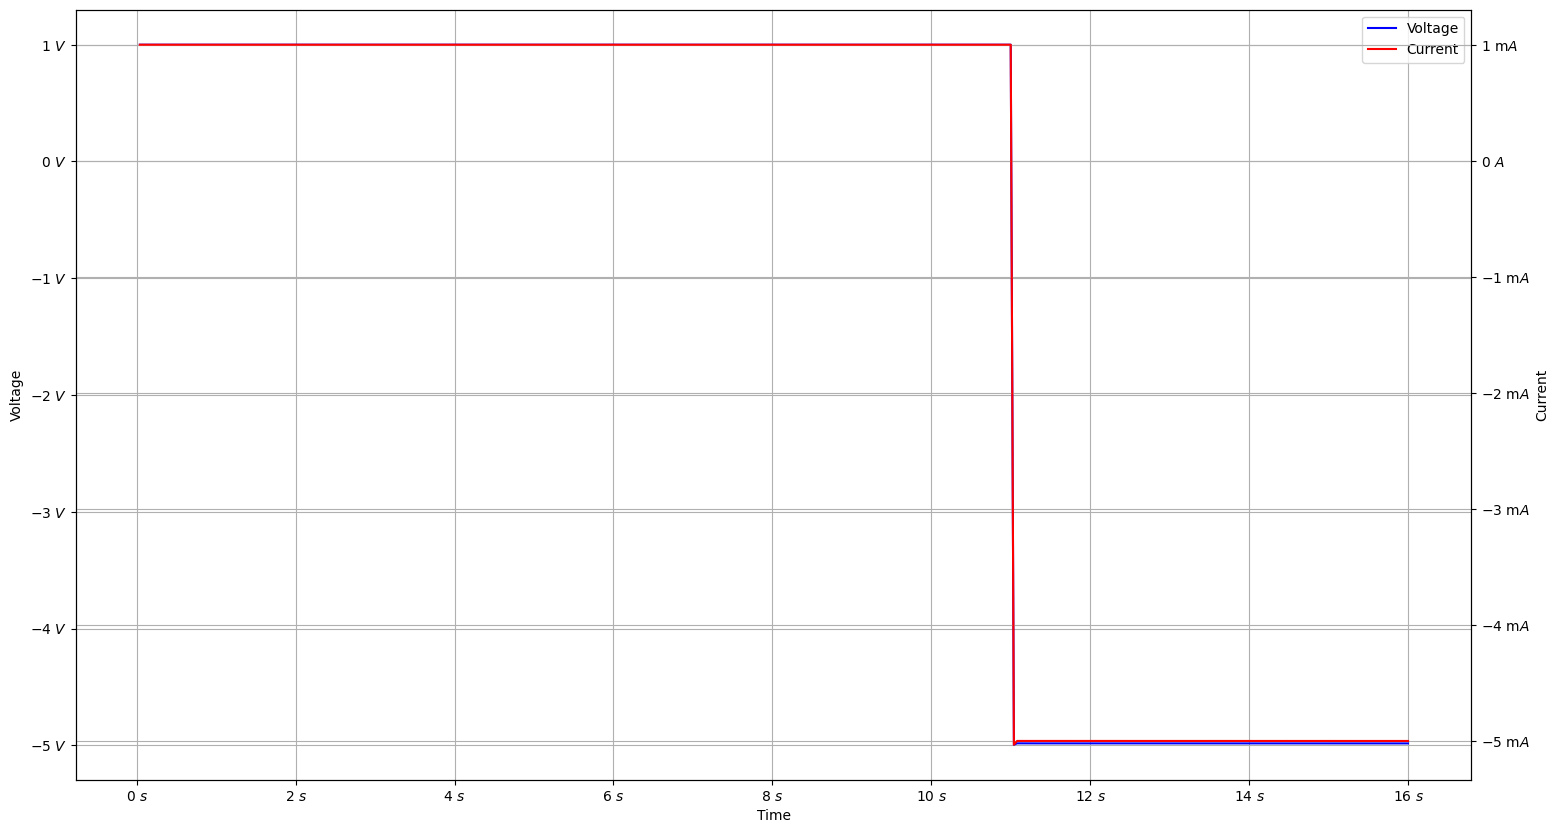

In [14]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
(line1,) = ax1.plot(time, voltage, color="blue", label="Voltage")
(line2,) = ax2.plot(time, current, color="red", label="Current")
ax1.legend(handles=[line1, line2])

ax1.xaxis.set_major_formatter(EngFormatter(unit="$s$"))
ax1.yaxis.set_major_formatter(EngFormatter(unit="$V$"))
ax1.set_xlabel("Time")
ax1.set_ylabel("Voltage")
ax1.grid(which="both")
ax2.xaxis.set_major_formatter(EngFormatter(unit="$s$"))
ax2.yaxis.set_major_formatter(EngFormatter(unit="$A$"))
ax2.set_xlabel("Time")
ax2.set_ylabel("Current")
ax2.grid(which="both")

fig.set_size_inches(18, 10)
plt.show()
fig.savefig("polarization.svg")